In [55]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd

In [56]:
data = pd.read_csv("train.csv")
df = pd.DataFrame(data)

df.head(10)

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0
5,5,15771669,Genovese,588,Germany,Male,36.0,4,131778.58,1,1.0,0.0,136024.31,1
6,6,15692819,Ch'ang,593,France,Female,30.0,8,144772.69,1,1.0,0.0,29792.11,0
7,7,15669611,Chukwuebuka,678,Spain,Male,37.0,1,138476.41,1,1.0,0.0,106851.60,0
8,8,15691707,Manna,676,France,Male,43.0,4,0.00,2,1.0,0.0,142917.13,0
9,9,15591721,Cattaneo,583,Germany,Male,40.0,4,81274.33,1,1.0,1.0,170843.07,0


In [57]:
# Shape (rows, columns)
print("Shape:", df.shape)

Shape: (165034, 14)


In [58]:
# Column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')


Your Goal: For this Episode of the Series, your task is to predict whether a customer continues with their account or closes it (e.g., churns). Good luck!

In [59]:
df.isnull().sum()

id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [60]:
df.dtypes

id                   int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object

In [61]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [53]:
def detect_outliers(df):
    outlier_counts = {}
    
    for col in df.select_dtypes(include=np.number).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_counts[col] = len(outliers)
    
    return outlier_counts

outliers = detect_outliers(df)

print("\nOutliers per Numerical Column:")
print(outliers)


Outliers per Numerical Column:
{'id': 0, 'CustomerId': 0, 'CreditScore': 253, 'Age': 6394, 'Tenure': 0, 'Balance': 0, 'NumOfProducts': 475, 'HasCrCard': 40606, 'IsActiveMember': 0, 'EstimatedSalary': 0, 'Exited': 34921}


In [63]:
target = "Exited"

print("\nTarget Distribution:")
print(df[target].value_counts())

print("\nTarget Distribution (%):")
print(df[target].value_counts(normalize=True) * 100)


Target Distribution:
Exited
0    130113
1     34921
Name: count, dtype: int64

Target Distribution (%):
Exited
0    78.840118
1    21.159882
Name: proportion, dtype: float64


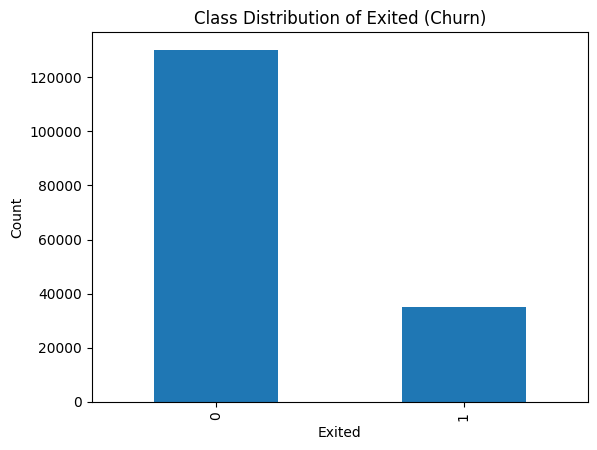

In [64]:
import matplotlib.pyplot as plt

df["Exited"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Exited (Churn)")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

In [65]:
summary = pd.DataFrame({
    'Feature': df.columns,
    'Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})

# Add categorical vs numerical
summary['Category'] = summary['Type'].apply(
    lambda x: 'Categorical' if x == 'object' else 'Numerical'
)

summary

,Feature,Type,Missing Values,Unique Values,Category
id,id,int64,0,165034,Numerical
CustomerId,CustomerId,int64,0,23221,Numerical
Surname,Surname,str,0,2797,Numerical
CreditScore,CreditScore,int64,0,457,Numerical
Geography,Geography,str,0,3,Numerical
Gender,Gender,str,0,2,Numerical
Age,Age,float64,0,71,Numerical
Tenure,Tenure,int64,0,11,Numerical
Balance,Balance,float64,0,30075,Numerical
NumOfProducts,NumOfProducts,int64,0,4,Numerical


In [68]:
if df[target].dtype == 'object' or df[target].nunique() < 20:
    print("\nLikely a CLASSIFICATION problem.")
    print("Classes:", df[target].unique())
else:
    print("\nLikely a REGRESSION problem.")
    print("Target Range:", df[target].min(), "to", df[target].max())


Likely a CLASSIFICATION problem.
Classes: [0 1]


In [69]:
class0 = df[df['Exited'] == 0]  # stayed
class1 = df[df['Exited'] == 1]  # churned

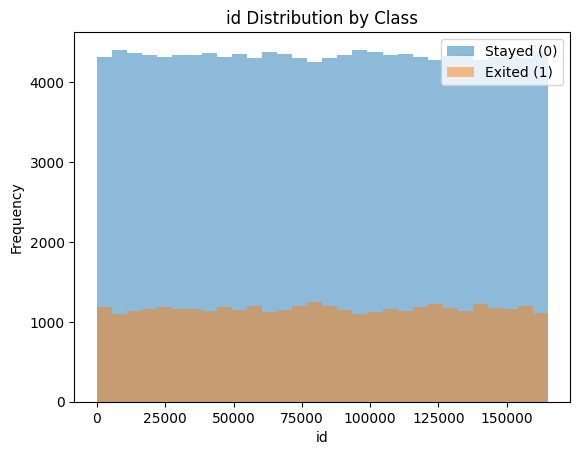

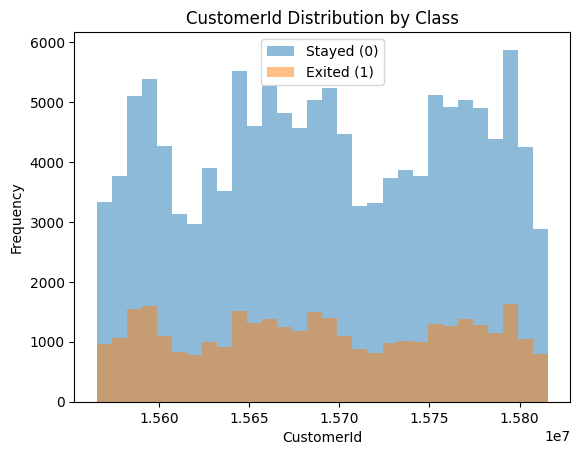

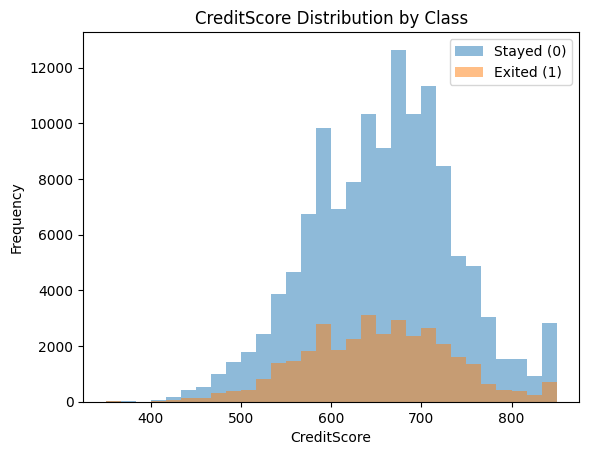

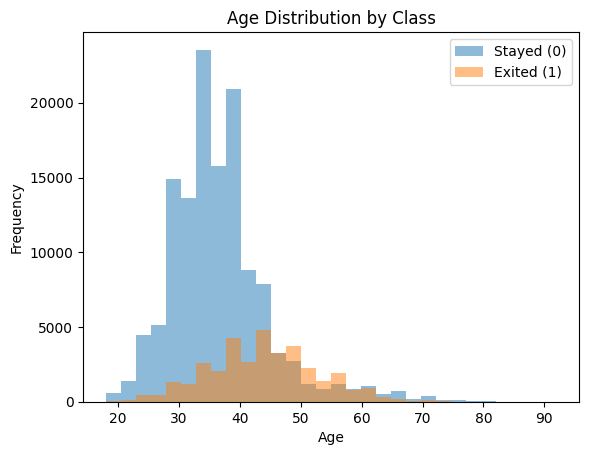

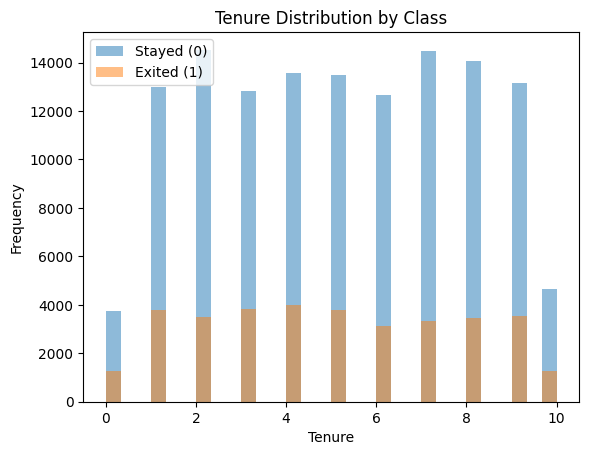

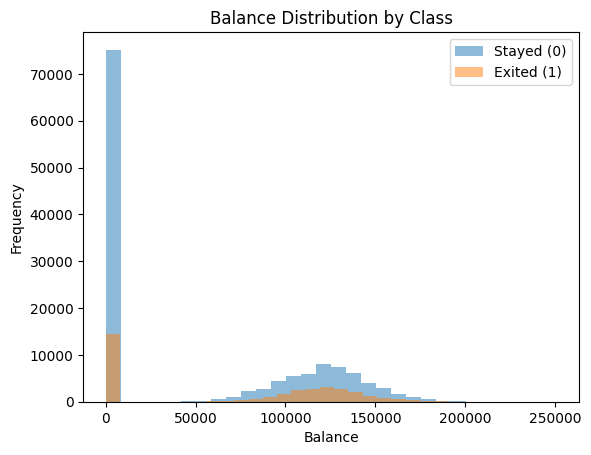

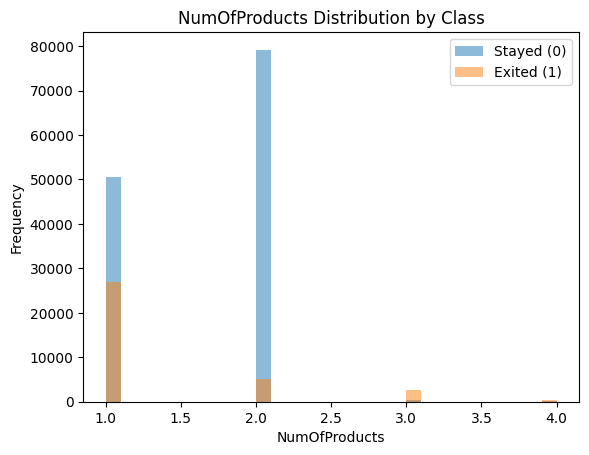

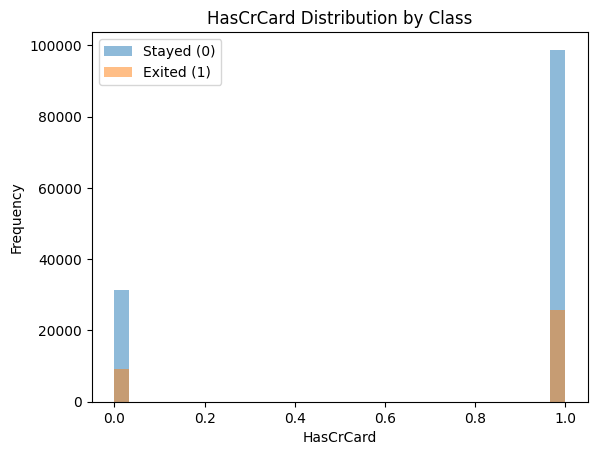

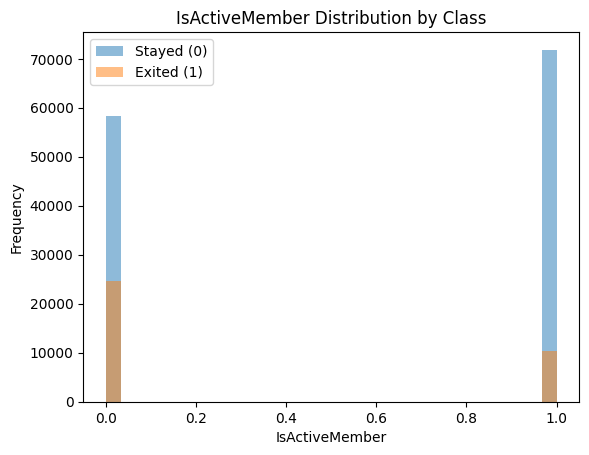

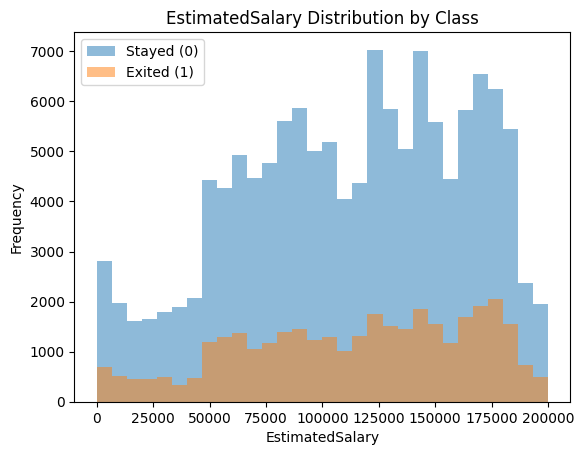

In [70]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Exited')  # don't include target

for col in num_cols:
    plt.figure()
    
    plt.hist(class0[col], bins=30, alpha=0.5, label='Stayed (0)')
    plt.hist(class1[col], bins=30, alpha=0.5, label='Exited (1)')
    
    plt.title(f'{col} Distribution by Class')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    
    plt.show()

NOTES: 
Age: It appears that adults (20-30s) churn more than younger individuals. Peak is around 40-50ish. 

Balance distribution: Massive spike at 0. Large portion of both who stayed and exited have a balance of 0. People with money in their accounts are normally distributed. 

Product Usage Thresholds: In the NumOfProducts graph, most customers have 1 or 2 products. However, the churn rate for customers with 3 or 4 products—the orange bars are much higher relative to the blue bars, suggests that customers with many products are actually more likely to leave.

Active Membership: The IsActiveMember graph shows a clear trend: inactive members (0) have a higher frequency of exiting compared to active members (1). Is pretty obvious. 

Uniform Distributions (Tenure & Salary): Features like Tenure and EstimatedSalary appear relatively uniform across both classes. This suggests that how long someone has been with the bank or how much they earn might not be as strong of a predictor for churn as Age or IsActiveMember.

The Credit Score "Ceiling": In the CreditScore distribution, there is a sharp spike at the far right (around 850). This represents a "ceiling effect" where many customers have the maximum possible score, but their churn behavior at that level looks fairly consistent with the rest of the population.

NOTES FOR BELOW:
Note: surnames are not useful for prediction
countries are useful: Germany has a higher churn rate, France has a lower churn rate, Spain is in between.
females tend to churn more than males, but the difference is not huge.

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(pd.crosstab(df[col], df['Exited'], normalize='index'))


--- Surname ---
Exited           0         1
Surname                     
Abazu     1.000000  0.000000
Abbie     0.750000  0.250000
Abbott    0.875000  0.125000
Abdullah  1.000000  0.000000
Abdulov   0.750000  0.250000
...            ...       ...
Zubarev   0.857143  0.142857
Zubareva  1.000000  0.000000
Zuev      0.842105  0.157895
Zuyev     0.775862  0.224138
Zuyeva    0.833333  0.166667

[2797 rows x 2 columns]

--- Geography ---
Exited            0         1
Geography                    
France     0.834718  0.165282
Germany    0.621048  0.378952
Spain      0.827824  0.172176

--- Gender ---
Exited         0         1
Gender                    
Female  0.720313  0.279687
Male    0.840945  0.159055


/var/folders/mn/mng3vpnn66d9h65m1_86tdfr0000gn/T/ipykernel_1463/1739725837.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


Clean data

In [31]:
df_clean = df.drop(['id', 'CustomerId', 'Surname'], axis=1)
print(df_clean.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Scaling

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.drop('Exited')

df_scaled = df_clean.copy()
df_scaled[num_cols] = scaler.fit_transform(df_clean[num_cols])

In [73]:
df_encoded = pd.get_dummies(df_scaled, columns=['Geography', 'Gender'], drop_first=True)

Categorical variables such as Geography and Gender were converted into numerical format using one-hot encoding. The first category was dropped to avoid multicollinearity.

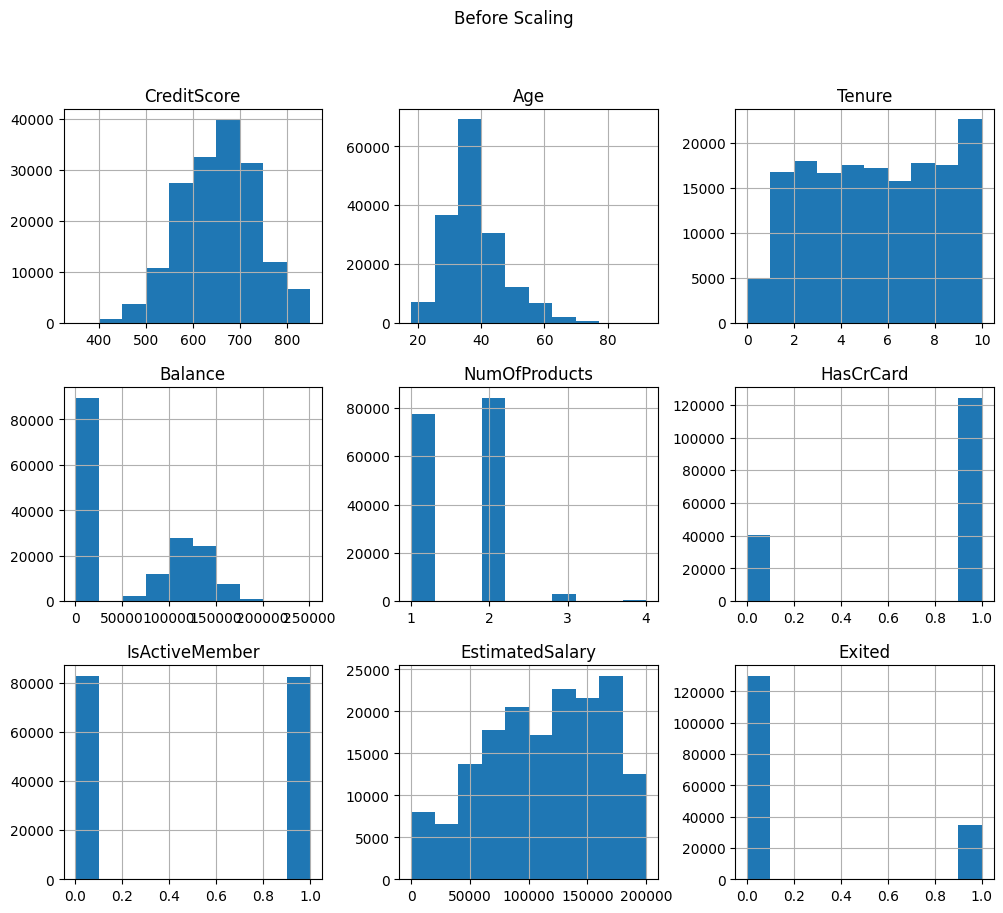

In [ ]:
# Before scaling
df_clean.hist(figsize=(12,10))
plt.suptitle("Before Scaling")
plt.show()

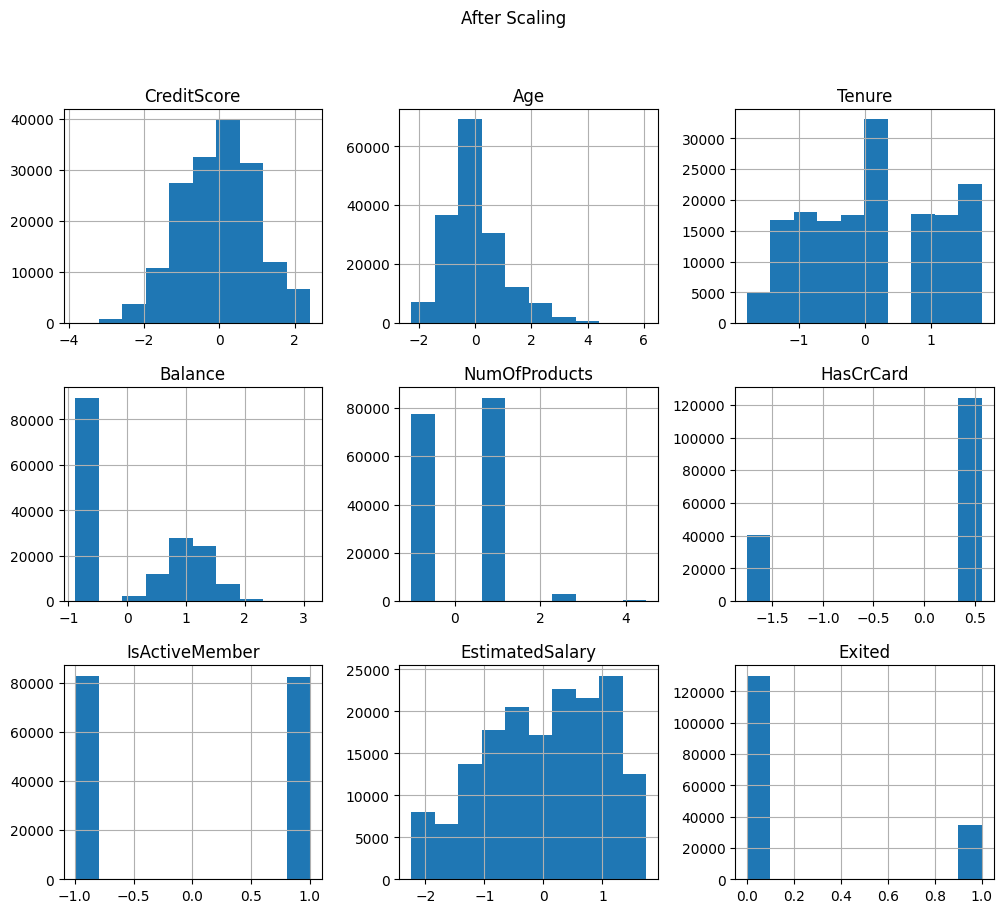

In [ ]:
# After Scaling
df_scaled.hist(figsize=(12,10))
plt.suptitle("After Scaling")
plt.show()


NOTES ABOVE:
1. Shape Preservation
The most important thing to notice is that the shape of every distribution remains identical. Scaling is a linear transformation; it changes the range of the data but does not "fix" skewness or outliers. For example:

The heavy right-skew in Age is still there.

The massive spike at zero for Balance remains.

The bimodal nature of IsActiveMember is unchanged.

2. Centering and ScalingIf 

Mean of 0: Most distributions are now centered around $0$.
Standard Deviation of 1: The values generally range between $-3$ and $+3$. 

For CreditScore, the original values $(\approx 400\text{ to }850)$ are now expressed as "how many standard deviations away from the average" a customer is.

3. Binary and Categorical FeaturesYou might notice that HasCrCard, IsActiveMember -> binary

In [36]:
X = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

Train ML

In [76]:
from sklearn.model_selection import train_test_split

# 70/30 split for train + temp, then 50/50 split for validation and test

# First split: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (115523, 11)
Validation: (24755, 11)
Test: (24756, 11)


Logistic Regression

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: define model
model = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: fit model
model.fit(X_train, y_train)

# Step 3: predict
y_val_pred = model.predict(X_val)

# Step 4: evaluate
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

Accuracy: 0.8329226418905271

Confusion Matrix:
 [[18611   893]
 [ 3243  2008]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.95      0.90     19504
           1       0.69      0.38      0.49      5251

    accuracy                           0.83     24755
   macro avg       0.77      0.67      0.70     24755
weighted avg       0.82      0.83      0.81     24755



In [40]:
from sklearn.metrics import roc_auc_score

y_val_prob = model.predict_proba(X_val)[:, 1]

print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))

ROC-AUC: 0.8134577358521811


Random Forrest

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
y_pred = rf.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.8553423550797818
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     19504
           1       0.71      0.54      0.61      5251

    accuracy                           0.86     24755
   macro avg       0.80      0.74      0.76     24755
weighted avg       0.85      0.86      0.85     24755



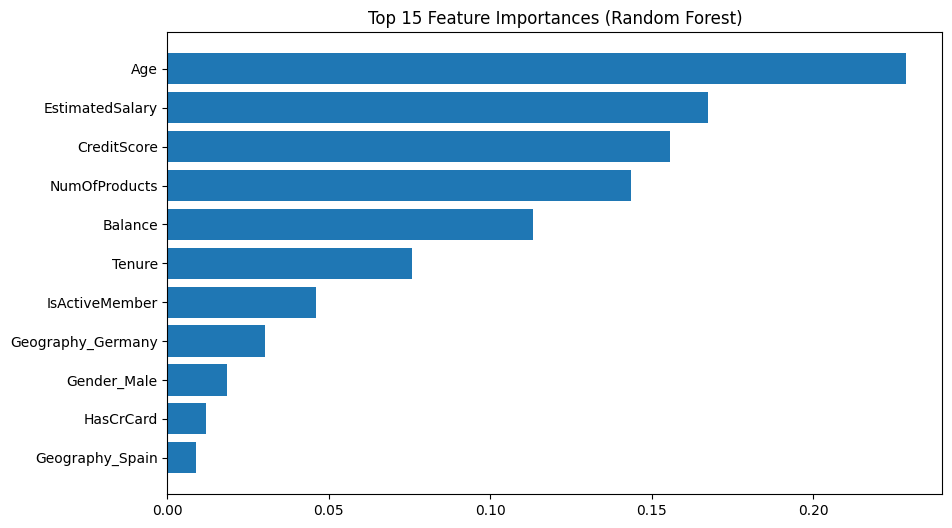

In [77]:
importances = rf.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_df["Feature"][:15][::-1], feat_df["Importance"][:15][::-1])
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

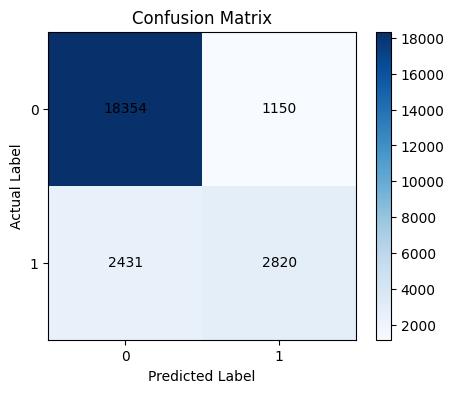

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# Add numbers inside the boxes
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.colorbar()
plt.xticks([0,1])
plt.yticks([0,1])

plt.show()

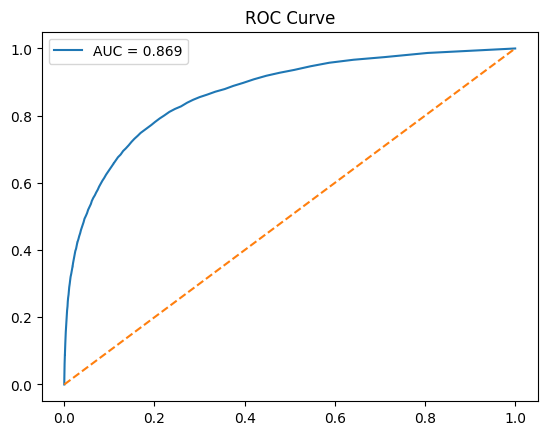

In [79]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_val)[:, 1]

fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.legend()
plt.show()

Apply to test (Random Forrest)

In [87]:
test_df = pd.read_csv("test.csv")

test_ids = test_df["id"]  # save IDs for submission

In [88]:
test_df = test_df.drop(["id", "CustomerId", "Surname"], axis=1)

test_df = pd.get_dummies(test_df, columns=["Geography", "Gender"], drop_first=True)

# Align columns with training data
test_df = test_df.reindex(columns=X.columns, fill_value=0)

In [90]:
final_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

final_model.fit(X, y)

test_predictions = final_model.predict(test_df)

submission = pd.DataFrame({
    'id': pd.read_csv('test.csv')['id'],
    'Exited': test_predictions
})

submission.to_csv('submission.csv', index=False)